In [5]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
# ── Step 1: Load Dataset ─────────────────────────────────────────────────────
# Each row = one house. MEDV is the target (median house price in $1000s).
data = pd.read_csv("Datasets/HousingData.csv")
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [7]:
# ── Step 2: Prepare Features and Labels ──────────────────────────────────────
X = data.drop("MEDV", axis=1)   # all columns except the price
y = data["MEDV"]                 # price is what we want to predict

# Some cells have missing values — fill them with the column average
X = X.fillna(X.mean())

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# ── Step 3: Feature Scaling ───────────────────────────────────────────────────
# Neural networks train better when all features are on the same scale (mean=0, std=1).
# fit_transform on train → only transform on test (avoid data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [9]:
# ── Step 4: Build the Model ───────────────────────────────────────────────────
# Dense(64) → Dense(32): two hidden layers with ReLU (learns non-linear patterns)
# Dense(1) with NO activation: regression output — can predict any numeric value
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))   # no activation = linear output for regression

# adam: adaptive optimizer | mse: penalises large errors more | mae: easy to interpret
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])


/opt/homebrew/Cellar/jupyterlab/4.4.0_1/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# ── Step 5: Train the Model ───────────────────────────────────────────────────
# epochs=100: enough passes for the small dataset to converge
# batch_size=16: update weights after every 16 samples
# validation_split=0.2: holds out 20% of training data to monitor overfitting
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Run predictions on the unseen test set
y_pred = model.predict(X_test)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 617.8415 - mae: 22.9518 - val_loss: 558.8746 - val_mae: 22.1186
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 616.8831 - mae: 22.9309 - val_loss: 557.9517 - val_mae: 22.0977
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 615.9250 - mae: 22.9102 - val_loss: 557.0354 - val_mae: 22.0770
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 614.9635 - mae: 22.8891 - val_loss: 556.1028 - val_mae: 22.0559
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 614.0048 - mae: 22.8680 - val_loss: 555.1746 - val_mae: 22.0348
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 613.0493 - mae: 22.8471 - val_loss: 554.2554 - val_mae: 22.0139
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 612.1010 - mae: 22.8265 - val_loss: 553.3535 - val_mae: 21.9935
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 611.1654 - mae: 22.8057 - val_loss: 552.4365 - val_mae: 21.9726
Epoch 9/10
21/21 ━━━━━━━


Model Performance
-------------------
MSE : 526.1584726574373
RMSE: 22.938144490290345
R2 Score: -6.174844252984263


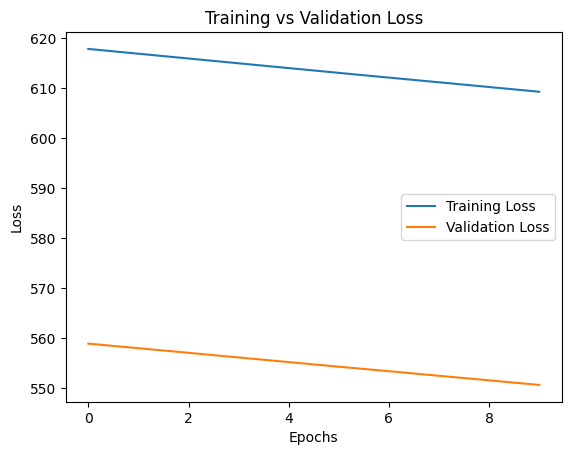

In [11]:
# ── Step 6: Evaluate & Visualise ─────────────────────────────────────────────
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

# R2 close to 1.0 = good. Negative = worse than predicting the mean.
print("\nModel Performance")
print("-------------------")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

# Loss curve — training and validation should both go down together
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Scatter: points close to the red diagonal = accurate predictions
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.show()